In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

HERE = Path(os.path.abspath(""))
ROOT = HERE.parent.parent.parent if HERE.name == "verify_gas_drag" else HERE
sys.path.insert(0, str(ROOT))

from spacehub_calc import load_spacehub_data_live, TwoBodyOrbit

In [2]:
def load_orbits(pattern):
    """Load simulation outputs, tolerant of incomplete/in-progress files.
    
    Automatically detects and concatenates '-resumed.dat' continuations.
    """
    orbits = {}
    for fpath in sorted(glob.glob(str(HERE / pattern))):
        if "FAILED" in fpath or "-resumed" in fpath:
            continue
        stem = Path(fpath).stem
        inc = float(stem.split("incl-")[-1])
        df = load_spacehub_data_live(fpath)
        if df is None or len(df) <= 2:
            continue

        # Check for a matching resumed file
        resumed_path = fpath.replace(".dat", "-resumed.dat")
        if os.path.exists(resumed_path):
            df_resumed = load_spacehub_data_live(resumed_path)
            if df_resumed is not None and len(df_resumed) > 2:
                df = pd.concat([df, df_resumed], ignore_index=True)
                # Deduplicate by (time, id) — NOT just time, since SpaceHub writes
                # one row per particle per timestep (all sharing the same time value).
                df = df.drop_duplicates(subset=["time", "id"], keep="last")
                df = df.sort_values("time").reset_index(drop=True)

        orbits[inc] = TwoBodyOrbit.from_dataframe(df, mute=True)
    return orbits

orbits_low  = load_orbits("out/ZengLowEcc/incl-*.dat")
orbits_high = load_orbits("out/ZengHighEcc/incl-*.dat")
print(f"Low-ecc  (e=0.3): {sorted(orbits_low)}")
print(f"High-ecc (e=0.7): {sorted(orbits_high)}")

Calculated c0 values are within 4.354 of constant (maximum - minimum)
Calculated c0 values are within 5.479 of constant (maximum - minimum)
Calculated c0 values are within 31.18 of constant (maximum - minimum)
Calculated c0 values are within nan of constant (maximum - minimum)
Calculated c0 values are within 5.208 of constant (maximum - minimum)
Calculated c0 values are within 50.41 of constant (maximum - minimum)
Calculated c0 values are within 59.03 of constant (maximum - minimum)
Calculated c0 values are within 73.8 of constant (maximum - minimum)
Calculated c0 values are within 39.76 of constant (maximum - minimum)
Low-ecc  (e=0.3): [20.0, 45.0, 120.0, 135.0, 170.0]
High-ecc (e=0.7): [90.0, 105.0, 120.0, 135.0]


| Parameter | Value |
|-----------|-------|
| M_SMBH | 1e8 M_sun |
| m_SMO | 30 M_sun (sBH) |
| Disk model | Sirko & Goodman (pagn) |
| alpha | 0.1 |
| l_e (Mdot/Mdot_Edd) | 0.5 |
| eps (radiative efficiency) | 0.1 |
| p_ini | 300 Rg |
| Force | Dynamical friction only |
| Inclinations | 20, 45, 90, 105, 120, 135, 170 deg |

In [ ]:
color_map = {20:"blue",
             45: "orange",
             90: "green",
             105: "red",
             120:"navy",
             135:"rebeccapurple",
             170:"black"}

# Geometrized length unit: GM/c^2 for M = 1e8 Msun, in AU
Mbullet_AU = 0.9853

# Geometrized time unit: T_M = GM/c^3  (in years)
# GM_sun/c^3 = 4.9255e-6 s
M_SMBH_Msun = 1e8
T_M_seconds = 4.9255e-6 * M_SMBH_Msun
T_M_years = T_M_seconds / 3.15576e7  # seconds per Julian year

def plot_zengpan(orbits_dict, e0, fignum):
    if not orbits_dict:
        print(f"No data for e={e0}")
        return None

    incs = sorted(orbits_dict)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

    for inc in incs:
        orb = orbits_dict[inc]
        t_Mbullet = orb.years / T_M_years        # t in M_bullet units
        a_Mbullet = np.array(orb.semiMajorAxis) / Mbullet_AU  # a in M_bullet
        e = np.array(orb.eccentricity)
        I = np.array(orb.inclination_deg)
        c = color_map[int(inc)]
        ls = '-' if inc < 90 else '--'
        lbl = f"{inc:.0f}°"

        axes[0].plot(t_Mbullet, a_Mbullet, color=c, lw=1.2, ls=ls, label=lbl)
        axes[1].plot(t_Mbullet, e, color=c, lw=1.2, ls=ls)
        axes[2].plot(t_Mbullet, I, color=c, lw=1.2, ls=ls)

    # Reference lines
    axes[0].axhline(10, color='blue', ls=':', lw=0.8, alpha=0.6)
    axes[2].axhline(90, color='black', ls=':', lw=0.8, alpha=0.6)

    axes[0].set(ylabel=r'$a\ [M_\bullet]$', xlabel=r'$t\ [M_\bullet]$')
    axes[1].set(ylabel=r'$e$', yscale='log', xlabel=r'$t\ [M_\bullet]$')
    axes[2].set(ylabel=r'$\iota\ [\mathrm{deg}]$', xlabel=r'$t\ [M_\bullet]$')
    for ax in axes:
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3)

    axes[0].legend(fontsize=8, ncol=2, loc='lower left')
    fig.suptitle(f'Fig {fignum}: Dynamical Friction, $e_{{\\mathrm{{ini}}}}={e0}$, $p_{{\\mathrm{{ini}}}}=300\\,M_\\bullet$',
                 fontsize=12)
    fig.tight_layout()
    return fig

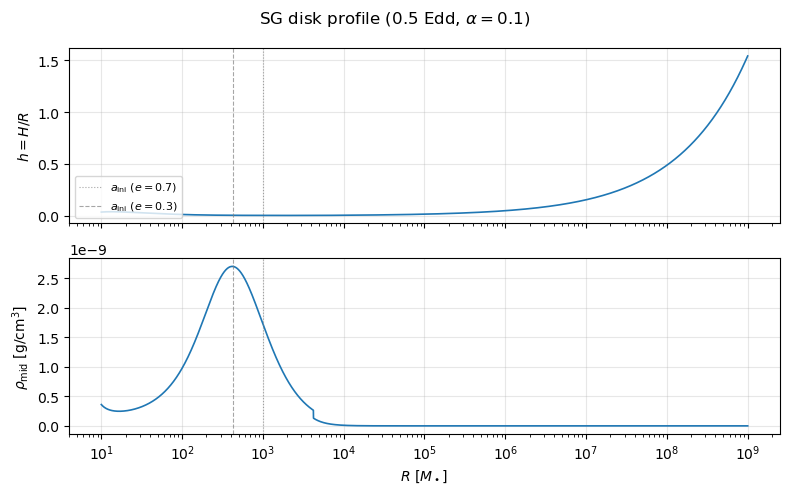

In [4]:
# Disk model reference: Sirko & Goodman, alpha=0.1, l_e=0.5
disk_ref = pd.read_csv(ROOT / "SpaceHub/src/interaction/disk_tab/SG_01Edd.csv")
R_Mb = disk_ref["R"].values / Mbullet_AU  # radius in M_bullet units

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

ax1.plot(R_Mb, disk_ref["H"].values / disk_ref["R"].values, lw=1.2)
ax1.set_ylabel(r'$h = H/R$')

Msun_g, AU_cm = 1.98847e33, 1.495978707e13
ax2.plot(R_Mb, disk_ref["rho"].values * Msun_g / AU_cm**3, lw=1.2)
ax2.set_ylabel(r'$\rho_{\rm mid}$ [g/cm$^3$]')
ax2.set_xlabel(r'$R\ [M_\bullet]$')

for ax in (ax1, ax2):
    ax.set_xscale('log')
    ax.axvline(1000, color='grey', ls=':', lw=0.8, alpha=0.7, label=r'$a_{\rm ini}$ ($e=0.7$)')
    ax.axvline(300 / 0.7, color='grey', ls='--', lw=0.8, alpha=0.7, label=r'$a_{\rm ini}$ ($e=0.3$)')
    ax.grid(True, alpha=0.3)

ax1.legend(fontsize=8, loc='lower left')
fig.suptitle('SG disk profile (0.5 Edd, $\\alpha=0.1$)', fontsize=12)
fig.tight_layout()
plt.show()

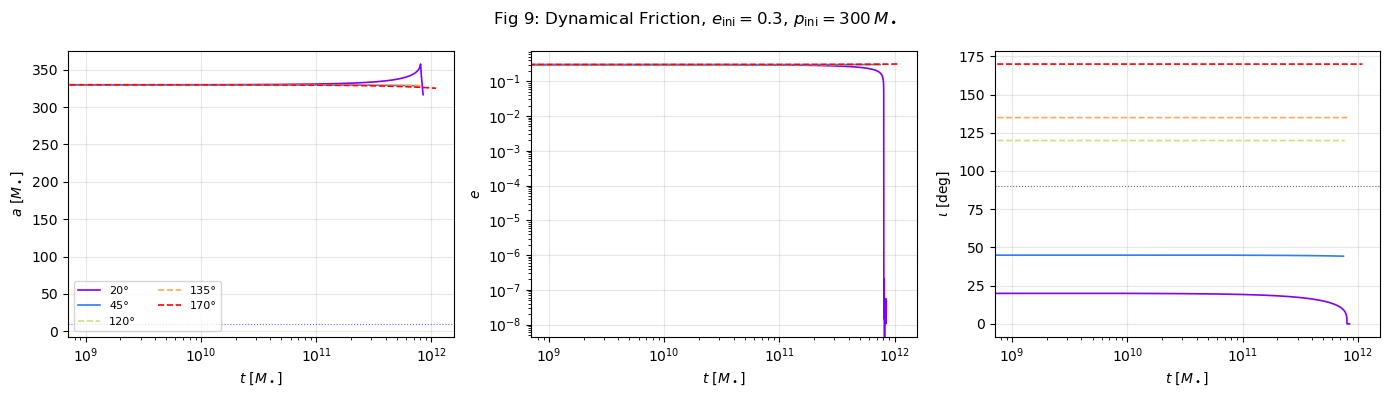

In [5]:
fig9 = plot_zengpan(orbits_low, e0=0.3, fignum=9)
plt.show()

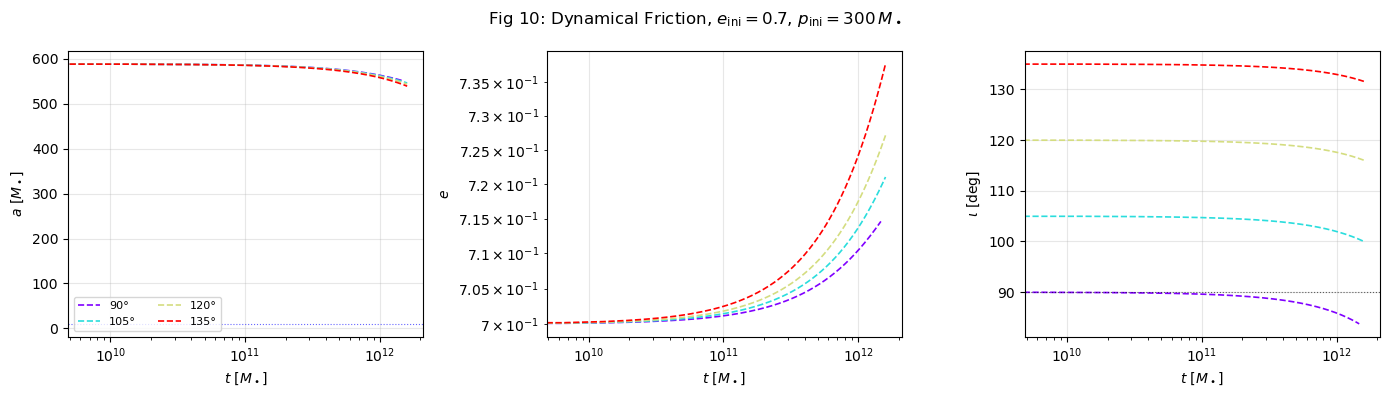

In [6]:
fig10 = plot_zengpan(orbits_high, e0=0.7, fignum=10)
plt.show()

In [7]:
disk_model_file = "SpaceHub/src/interaction/disk_tab/SG_01Edd.csv"
fp = "out/ZengHighEcc/incl-90.dat"
orb = TwoBodyOrbit(fp)

load data complete
Determining timesteps...
Calculating orbital state vectors...
Calculating scalar orbital elements...
Calculated c0 values are within 39.76 of constant (maximum - minimum)
Done


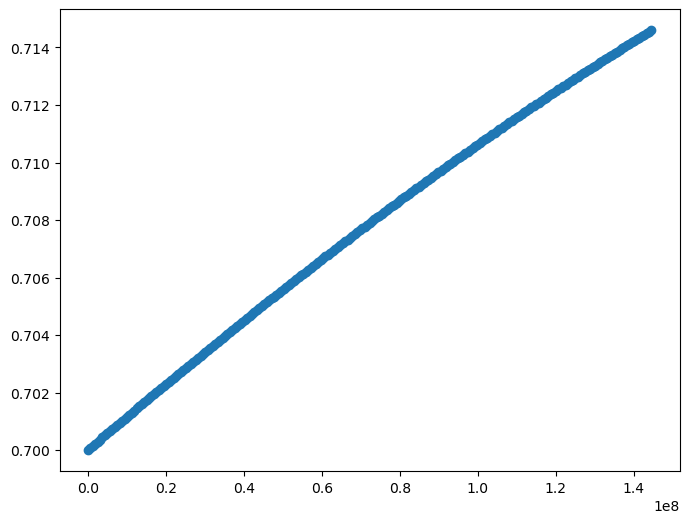

In [8]:
#@Claude, use this as a template to create simple plots in this notebook
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(x=orb.time, y=orb.eccentricity)

In [9]:
from scipy.interpolate import interp1d

# Load disk table (SpaceHub units: R in AU, H in AU, rho in Msun/AU^3)
disk = pd.read_csv(ROOT / disk_model_file)
disk_R = disk["R"].values
H_interp = interp1d(disk_R, disk["H"].values, bounds_error=False, fill_value="extrapolate")
rho_interp = interp1d(disk_R, disk["rho"].values, bounds_error=False, fill_value="extrapolate")

# Unit conversion: SpaceHub density -> cgs
Msun_g = 1.98847e33
AU_cm  = 1.495978707e13
rho_to_cgs = Msun_g / AU_cm**3

f_grid = np.linspace(0, 2 * np.pi, 2000, endpoint=False)

def embeddedness(a, e, inc, omega):
    """Time-weighted fraction of orbit with |z| < H(r), vectorized over f."""
    r = a * (1 - e**2) / (1 + e * np.cos(f_grid))
    z = r * np.sin(inc) * np.sin(omega + f_grid)
    H = H_interp(r)
    w = r**2
    return np.sum(w * (np.abs(z) < H)) / np.sum(w)

# Compute disk properties for each inclination in orbits_high
disk_data = {}
for inc, orb in orbits_high.items():
    a_AU = np.array(orb.semiMajorAxis)
    t_Mb = orb.years / T_M_years
    H_t  = H_interp(a_AU)
    h_t  = H_t / a_AU
    rho_t = rho_interp(a_AU) * rho_to_cgs

    e_arr = np.array(orb.eccentricity)
    i_rad = np.deg2rad(np.array(orb.inclination_deg))
    w_rad = np.deg2rad(np.array(orb.argument_of_periapsis_deg))
    ef = np.array([embeddedness(a_AU[j], e_arr[j], i_rad[j], w_rad[j])
                   for j in range(len(a_AU))])

    disk_data[inc] = dict(t=t_Mb, h=h_t, rho=rho_t, embed=ef)

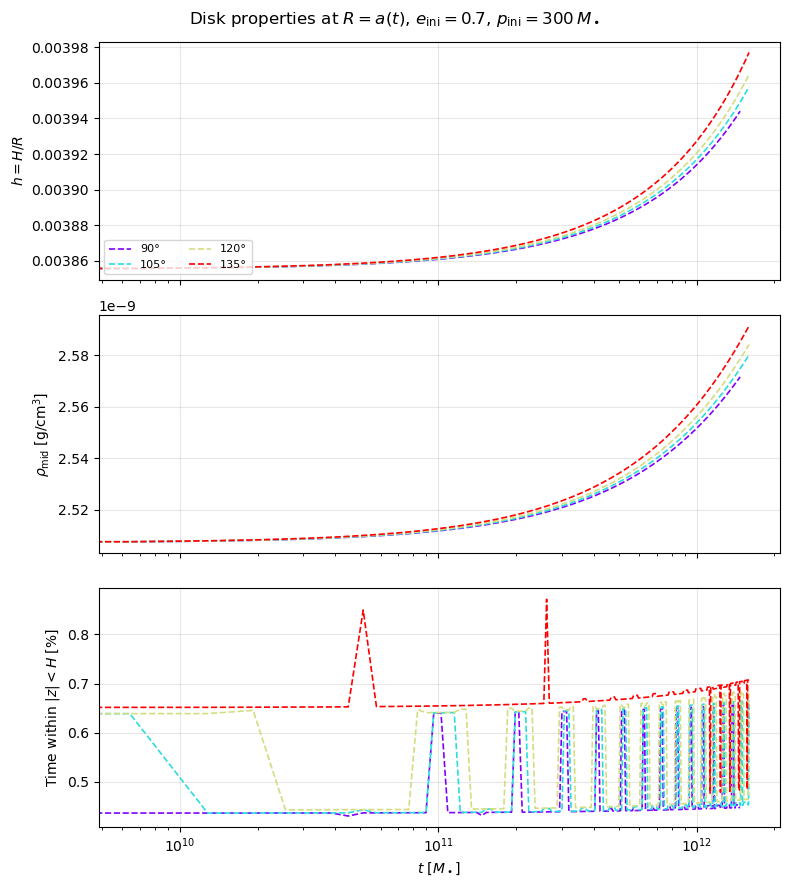

In [10]:
cmap = cm.rainbow
incs = sorted(disk_data)
norm = plt.Normalize(vmin=min(incs), vmax=max(incs))

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

for inc in incs:
    d = disk_data[inc]
    c = cmap(norm(inc))
    ls = '-' if inc < 90 else '--'
    lbl = f"{inc:.0f}°"

    axes[0].plot(d['t'], d['h'],          color=c, lw=1.2, ls=ls, label=lbl)
    axes[1].plot(d['t'], d['rho'],         color=c, lw=1.2, ls=ls)
    axes[2].plot(d['t'], d['embed'] * 100, color=c, lw=1.2, ls=ls)

axes[0].set_ylabel(r'$h = H/R$')
axes[0].legend(fontsize=8, ncol=2, loc='lower left')
axes[1].set_ylabel(r'$\rho_{\rm mid}$ [g/cm$^3$]')
axes[2].set_ylabel(r'Time within $|z|<H$ [%]')
axes[2].set_xlabel(r'$t\ [M_\bullet]$')

for ax in axes:
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

fig.suptitle(r'Disk properties at $R = a(t)$, $e_{\mathrm{ini}}=0.7$, $p_{\mathrm{ini}}=300\,M_\bullet$',
             fontsize=12)
fig.tight_layout()
plt.show()